In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [29]:
import h5py
train_dataset = h5py.File(r'E:\Pyhton code\Data Sets\archive\Cat vs Non Cat\train_catvnoncat.h5')
test_dataset = h5py.File(r'E:\Pyhton code\Data Sets\archive\Cat vs Non Cat\test_catvnoncat.h5')

In [30]:
train_x_orig = np.array(train_dataset["train_set_x"][:])
train_y = np.array(train_dataset["train_set_y"][:])

test_x_orig = np.array(test_dataset["test_set_x"][:])
test_y = np.array(test_dataset["test_set_y"][:])

classes = np.array(test_dataset["list_classes"][:])

In [31]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]
train_y = train_y.reshape(1,-1)
test_y = test_y.reshape(1,-1)

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [32]:
# Reshape the training and test examples 
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


In [33]:
### CONSTANTS DEFINING THE MODEL ####
n_x = 12288     # num_px * num_px * 3
n_h = 7
n_y = 1
layers_dims = (n_x, n_h, n_y)
learning_rate = 0.0075

In [34]:
def initialize_parameters(n_x, n_h, n_y):

    np.random.seed(1)

    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))

    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))

    parameters = {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2
    }

    return parameters

In [35]:
def linear_activation_forward(A_prev, W, b, activation):

    if activation == "sigmoid":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)

    elif activation == "relu":
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = relu(Z)

    cache = (linear_cache, activation_cache)

    return A, cache

In [36]:
def linear_forward(A, W, b):
    
    Z = np.dot(W, A) + b

    cache = (A, W, b)

    return Z, cache

In [37]:
def relu(Z):
    """
    Implement the RELU function.
    """

    A = np.maximum(0, Z)

    cache = Z

    return A, cache

In [38]:
def sigmoid(Z):
    """
    Implement the sigmoid activation.
    """

    A = 1 / (1 + np.exp(-Z))

    cache = Z

    return A, cache

In [39]:
def sigmoid_backward(dA, cache):

    Z = cache

    s = 1 / (1 + np.exp(-Z))

    dZ = dA * s * (1 - s)

    return dZ

In [42]:
def compute_cost(AL, Y):
    """
    Implement the cross-entropy cost.
    """

    m = Y.shape[1]

    cost = -(1/m) * np.sum(
        Y * np.log(AL) +
        (1 - Y) * np.log(1 - AL)
    )

    cost = np.squeeze(cost)

    return cost

In [47]:
def linear_activation_backward(dA, cache, activation):

    linear_cache, activation_cache = cache

    if activation == "relu":

        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    elif activation == "sigmoid":

        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)

    return dA_prev, dW, db

In [50]:
def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer.
    """

    A_prev, W, b = cache

    m = A_prev.shape[1]

    dW = (1/m) * np.dot(dZ, A_prev.T)
    db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db

In [53]:
def relu_backward(dA, cache):
    """
    Implement the backward propagation for a single RELU unit.
    """

    Z = cache

    dZ = np.array(dA, copy=True)

    dZ[Z <= 0] = 0

    return dZ

In [57]:
# GRADED FUNCTION: two_layer_model

def two_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False): 
    np.random.seed(1)
    grads = {}
    costs = []                              # to keep track of the cost
    m = X.shape[1]                           # number of examples
    (n_x, n_h, n_y) = layers_dims
    
    
    parameters = initialize_parameters(n_x, n_h, n_y)
    
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    
    # Loop (gradient descent)

    for i in range(0, num_iterations):
        A1, cache1 = linear_activation_forward(X, W1, b1, "relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, "sigmoid") 
        cost = compute_cost(A2, Y)
        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))
        dA1, dW2, db2 = linear_activation_backward(
        dA2,
        cache2,
        "sigmoid"
            )

        dA0, dW1, db1 = linear_activation_backward(
        dA1,
        cache1,
        "relu"
            ) 
    
        grads['dW1'] = dW1
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2
        
        parameters = update_parameters(
        parameters,
        grads,
        learning_rate
            )
        
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        
        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
            
    return parameters, costs

def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('iterations (per hundreds)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

In [56]:
import copy

def update_parameters(params, grads, learning_rate):

    parameters = copy.deepcopy(params)

    L = len(parameters) // 2

    for l in range(L):

        parameters["W" + str(l + 1)] = (
            parameters["W" + str(l + 1)]
            - learning_rate * grads["dW" + str(l + 1)]
        )

        parameters["b" + str(l + 1)] = (
            parameters["b" + str(l + 1)]
            - learning_rate * grads["db" + str(l + 1)]
        )

    return parameters

Cost after iteration 0: 0.693049735659989
Cost after iteration 100: 0.6464320953428849
Cost after iteration 200: 0.6325140647912677
Cost after iteration 300: 0.6015024920354665
Cost after iteration 400: 0.5601966311605747
Cost after iteration 500: 0.5158304772764729
Cost after iteration 600: 0.4754901313943325
Cost after iteration 700: 0.4339163151225749
Cost after iteration 800: 0.4007977536203889
Cost after iteration 900: 0.3580705011323798
Cost after iteration 1000: 0.3394281538366412
Cost after iteration 1100: 0.3052753636196264
Cost after iteration 1200: 0.2749137728213016
Cost after iteration 1300: 0.2468176821061486
Cost after iteration 1400: 0.19850735037466102
Cost after iteration 1500: 0.17448318112556607
Cost after iteration 1600: 0.17080762978096245
Cost after iteration 1700: 0.11306524562164731
Cost after iteration 1800: 0.09629426845937153
Cost after iteration 1900: 0.08342617959726863
Cost after iteration 2000: 0.07439078704319084
Cost after iteration 2100: 0.06630748132

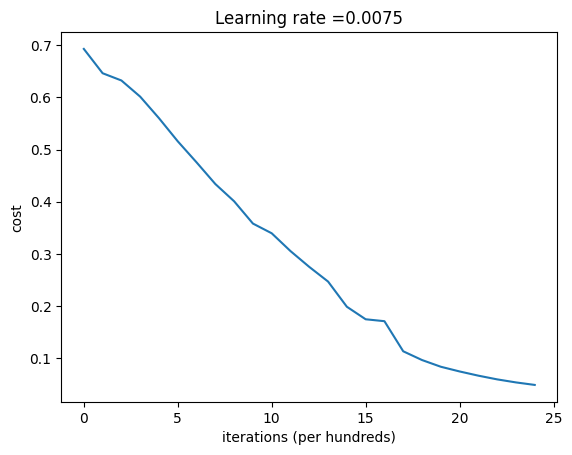

In [58]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)
plot_costs(costs, learning_rate)

In [60]:
def predict(X, y, parameters):
    """
    Predicts the results of a L-layer neural network.
    """

    m = X.shape[1]

    probas, caches = L_model_forward(X, parameters)

    p = (probas > 0.5).astype(int)

    print("Accuracy: " + str(np.sum((p == y) / m)))

    return p

In [62]:
def L_model_forward(X, parameters):
    """
    Implement forward propagation for the
    [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID computation
    """

    caches = []
    A = X
    L = len(parameters) // 2

    # Hidden layers: LINEAR -> RELU
    for l in range(1, L):

        A_prev = A

        A, cache = linear_activation_forward(
            A_prev,
            parameters["W" + str(l)],
            parameters["b" + str(l)],
            activation="relu"
        )

        caches.append(cache)

    # Output layer: LINEAR -> SIGMOID
    AL, cache = linear_activation_forward(
        A,
        parameters["W" + str(L)],
        parameters["b" + str(L)],
        activation="sigmoid"
    )

    caches.append(cache)

    return AL, caches

In [63]:
predictions_train = predict(train_x, train_y, parameters)

Accuracy: 0.9999999999999998


In [64]:
predictions_test = predict(test_x, test_y, parameters)

Accuracy: 0.72


In [65]:
### CONSTANTS ###
layers_dims = [12288, 20, 7, 5, 1] #  4-layer model

In [71]:
# GRADED FUNCTION: L_layer_model

def L_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    
    np.random.seed(1)
    costs = []                         # keep track of cost
    parameters = initialize_parameters_deep(layers_dims)
    
    # YOUR CODE ENDS HERE
    
    # Loop (gradient descent)
    for i in range(0, num_iterations):
        AL, caches = L_model_forward(X, parameters)
        cost = compute_cost(AL, Y)
        grads = L_model_backward(AL, Y, caches)
        
        parameters = update_parameters(
        parameters,
        grads,
        learning_rate
            )
        
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)
    
    return parameters, costs

In [69]:
def initialize_parameters_deep(layer_dims):
    """
    layer_dims -- list containing dimensions of each layer
                  e.g. [12288, 20, 7, 5, 1]
    """

    np.random.seed(3)

    parameters = {}
    L = len(layer_dims)

    for l in range(1, L):

        parameters["W" + str(l)] = (
            np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.01
        )

        parameters["b" + str(l)] = np.zeros((layer_dims[l], 1))

    return parameters

In [73]:
def L_model_backward(AL, Y, caches):
    """
    Implement the backward propagation for the
    [LINEAR->RELU] * (L-1) -> LINEAR->SIGMOID group
    """

    grads = {}
    L = len(caches)

    Y = Y.reshape(AL.shape)

    # Initializing the backpropagation
    dAL = -(np.divide(Y, AL) -
            np.divide(1 - Y, 1 - AL))

    # Last layer (SIGMOID -> LINEAR)
    current_cache = caches[L - 1]

    dA_prev_temp, dW_temp, db_temp = linear_activation_backward(
        dAL,
        current_cache,
        activation="sigmoid"
    )

    grads["dA" + str(L - 1)] = dA_prev_temp
    grads["dW" + str(L)] = dW_temp
    grads["db" + str(L)] = db_temp

    # Remaining layers (RELU -> LINEAR)
    for l in reversed(range(L - 1)):

        current_cache = caches[l]

        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(
            grads["dA" + str(l + 1)],
            current_cache,
            activation="relu"
        )

        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads

In [77]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 1, print_cost = False)

print("Cost after first iteration: " + str(costs[0]))

Cost after first iteration: 0.6931477726958


In [74]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Cost after iteration 0: 0.6931477726958
Cost after iteration 100: 0.6780107728090446
Cost after iteration 200: 0.6675997530076283
Cost after iteration 300: 0.6604218729413204
Cost after iteration 400: 0.6554578158288099
Cost after iteration 500: 0.6520134603618388
Cost after iteration 600: 0.649615817609133
Cost after iteration 700: 0.6479417374612982
Cost after iteration 800: 0.6467696408278701
Cost after iteration 900: 0.6459469904244376
Cost after iteration 1000: 0.6453683565180596
Cost after iteration 1100: 0.6449605941011141
Cost after iteration 1200: 0.6446727774747648
Cost after iteration 1300: 0.6444693397903307
Cost after iteration 1400: 0.6443253714906714
Cost after iteration 1500: 0.6442233840298892
Cost after iteration 1600: 0.6441510728582549
Cost after iteration 1700: 0.6440997647032185
Cost after iteration 1800: 0.6440633362006798
Cost after iteration 1900: 0.6440374583192076
Cost after iteration 2000: 0.6440190669815907
Cost after iteration 2100: 0.6440059911782885
Cost

In [75]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 0.6555023923444976


In [76]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 0.3400000000000001


In [79]:
from PIL import  Image

Accuracy: 0.0
y = 0, your L-layer model predicts a "non-cat" picture.


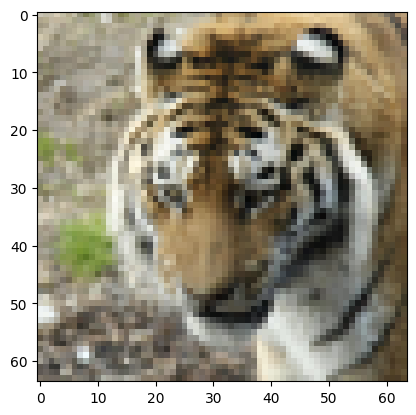

In [81]:
## START CODE HERE ##
my_image = r"E:\Pyhton code\Data Sets\archive\Unsupervised Animal Classification\dataset\0.jpg" # change this to the name of your image file 
my_label_y = [1] # the true class of your image (1 -> cat, 0 -> non-cat)
## END CODE HERE ##

image = np.array(Image.open(my_image).resize((num_px, num_px)))
plt.imshow(image)
image = image / 255.
image = image.reshape((1, num_px * num_px * 3)).T

my_predicted_image = predict(image, my_label_y, parameters)


print ("y = " + str(np.squeeze(my_predicted_image)) + ", your L-layer model predicts a \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\" picture.")